In [1]:
import numpy as np
import pickle
from itertools import product
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Geneva'
dpi=150

# $M$-uniform ER - steady state vs $\epsilon$

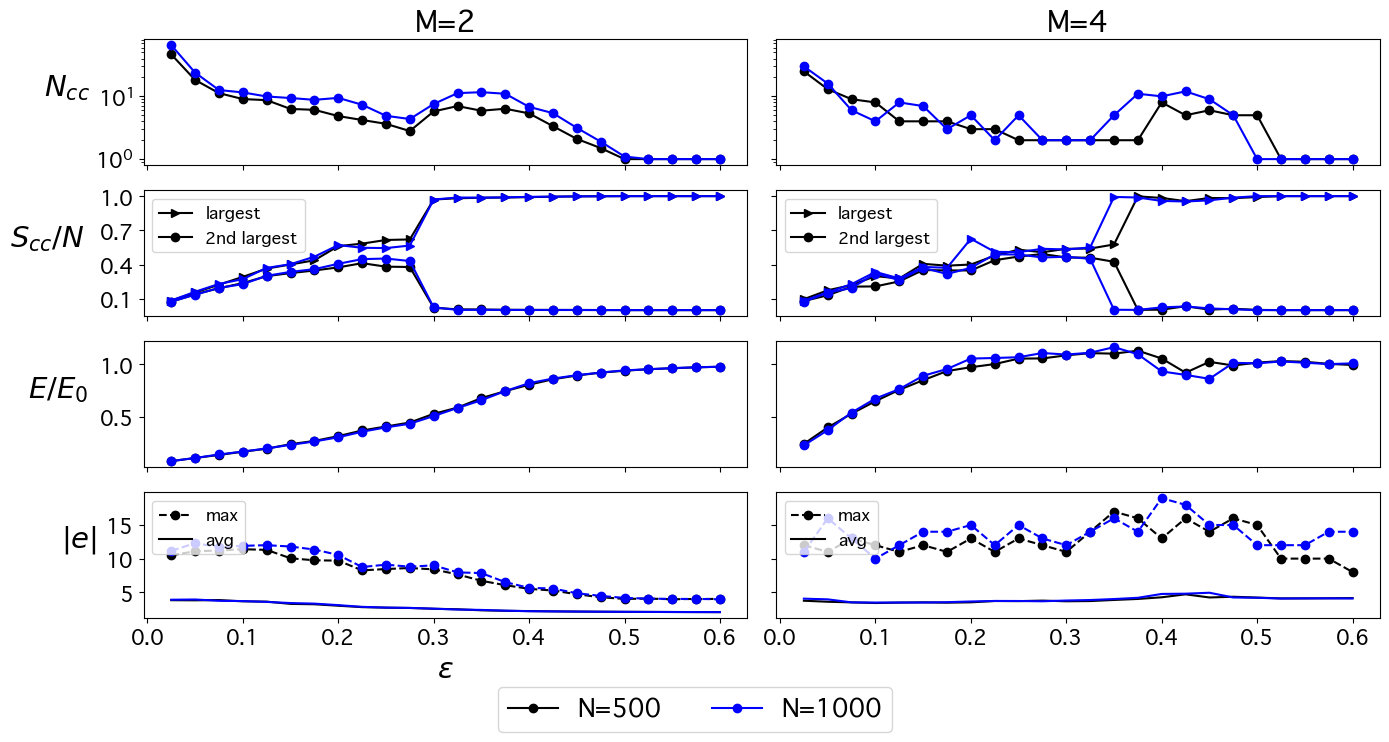

In [9]:
cond = 'max_min' 
Ns = [500, 1000]#, 2000, 5000]
Ms = [2, 4]#, 6]

nrows, ncols = 4, len(Ms)
fig, axs = plt.subplots(nrows, ncols, sharex=True, sharey='row', figsize=(14, 4*len(Ms)))
ttl_size = 21
lgd_size = 12
tick_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_{cond}/ER_{cond}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[0] else None
        la1 = lbls[1] if N==Ns[0] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=la1)
        tk = [0.1,0.4,0.7,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        axs[1,i].legend(fontsize=lgd_size, loc=2)
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')

        la2 = lbls[2] if N==Ns[0] else None
        la3 = lbls[3] if N==Ns[0] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        axs[3,i].legend(fontsize=lgd_size, loc=2)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)

    axs[0,i].set_title(f'M={M}', fontsize=ttl_size)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size, labelpad=20)

for j in range(ncols-1):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=(0.5, 0.002), fontsize=18, ncol=len(Ns))

plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.savefig(f'../figures/ER_{cond}.jpg', dpi=dpi)
plt.show()

# $M$-uniform ER - distributions for $\epsilon = 0.1$

M=2, N=500 ---> <k> = 3.0671626865074604
M=2, N=1000 ---> <k> = 3.181583631672633
M=2, N=2000 ---> <k> = 3.28035
M=2, N=5000 ---> <k> = 3.338097466729068
M=4, N=500 ---> <k> = 5.590223608944355
M=4, N=1000 ---> <k> = 5.768190727629105
M=4, N=2000 ---> <k> = 5.8457338293531755
M=4, N=5000 ---> <k> = 5.929896915464281
M=6, N=500 ---> <k> = 7.310089614338295
M=6, N=1000 ---> <k> = 7.506330126602533
M=6, N=2000 ---> <k> = 7.602392167451722
M=6, N=5000 ---> <k> = 6.959184489946148


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1242/3580769312.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


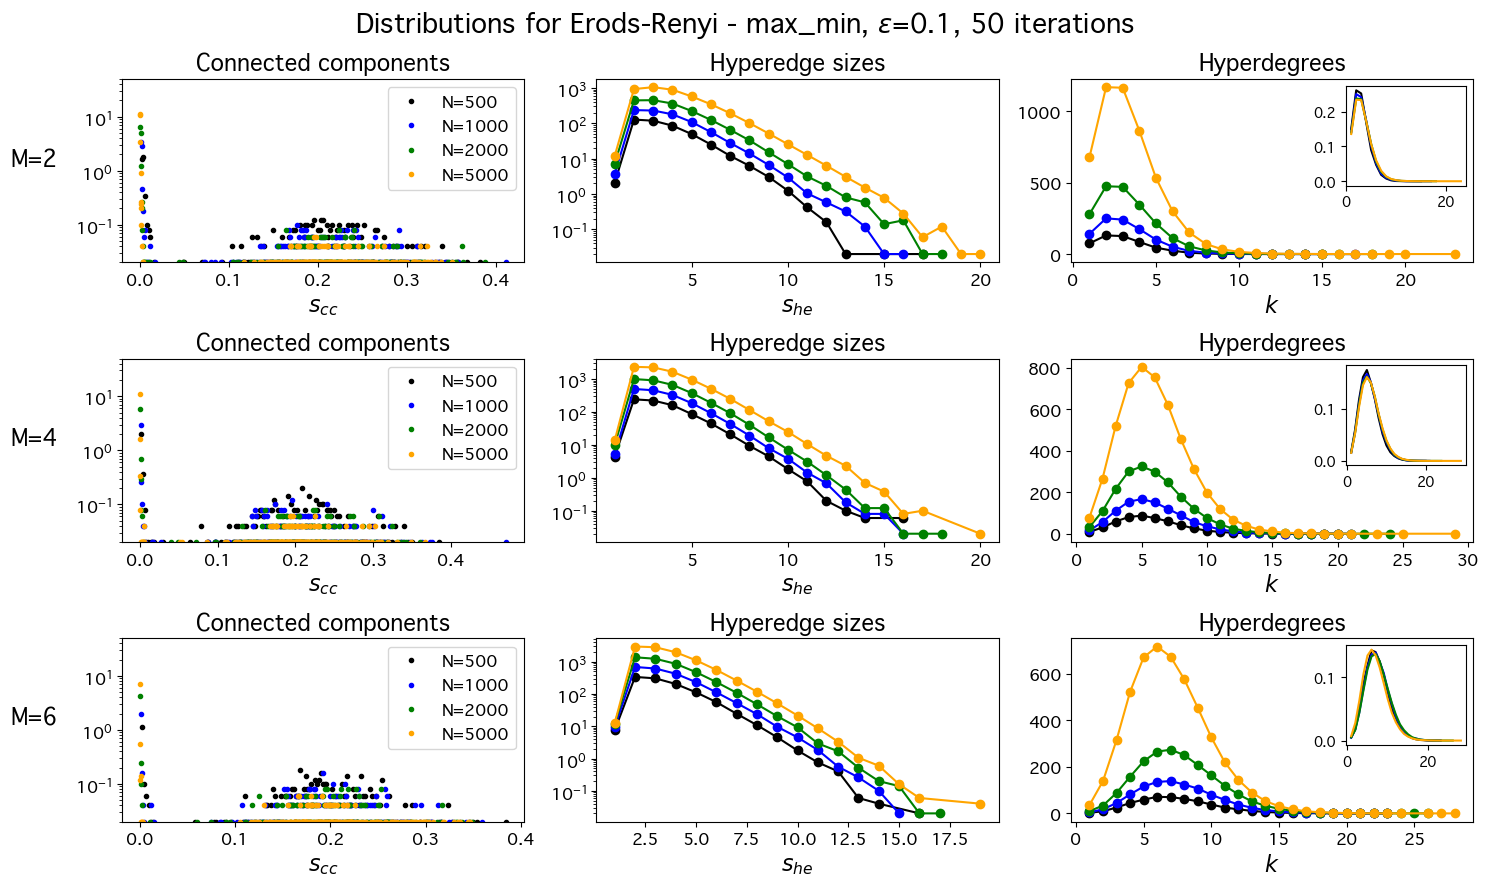

In [21]:
cond = 'max_min'
epsilon = 0.1
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

ncol = 3
fig, axs = plt.subplots(len(Ms), ncol, figsize=(15, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_{cond}/ER_{cond}_distrib_eps_{epsilon}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    sizes_cc = results['sizes_cc']
    sizes_he = results['sizes_he']
    sizes_hd = results['sizes_hd']
    n_iter = results['n_iterations']
    k_avg = results['k_avg']

    i = Ms.index(M)
    inset_ax = inset_axes(axs[i,2], width="30%", height=1.)
    for N,clr in zip(Ns, colors):
        
        x0 = [j/N for j in sorted(sizes_cc[N].keys())]
        y0 = [sizes_cc[N][j] for j in sorted(sizes_cc[N].keys())]
        axs[i,0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0, label=f'N={N}')
        axs[i,0].set_yscale('log')
        axs[i,0].set_ylim([1/n_iter, n_iter])
        axs[i,0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
        axs[i,0].set_title('Connected components', rotation=0, fontsize=ttl_size)
        axs[i,0].legend(fontsize=lgd_size)

        x1 = sorted(sizes_he[N].keys())
        y1 = [sizes_he[N][x] for x in x1]
        axs[i,1].plot(x1, y1, color=clr, marker='o', label=f'N={N}')
        axs[i,1].set_yscale('log')        
        axs[i,1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
        axs[i,1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

        x2 = sorted(sizes_hd[N].keys())
        y2 = [sizes_hd[N][x] for x in x2]
        axs[i,2].plot(x2, y2, color=clr, marker='o', label=f'N={N}')
        axs[i,2].set_xlabel(r'$k$', fontsize=ttl_size)
        axs[i,2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)
        # inset plots
        y2_norm = [i/N for i in y2]
        inset_ax.plot(x2, y2_norm, color=clr)
        
        # print avg hyperdegree
        hd_avg = np.dot(x2, y2) / sum(y2)
        print(f'M={M}, N={N} ---> <k> = {hd_avg}')

        # set tick fontsize in all subplots
        for j in range(3):
            axs[i,j].tick_params(labelsize=12)
            
    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

plt.suptitle(rf'Distributions for Erods-Renyi - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_distributions_eps_{epsilon}.jpg', dpi=dpi)
plt.show()

# Non-uniform ER - steady state vs $\epsilon$

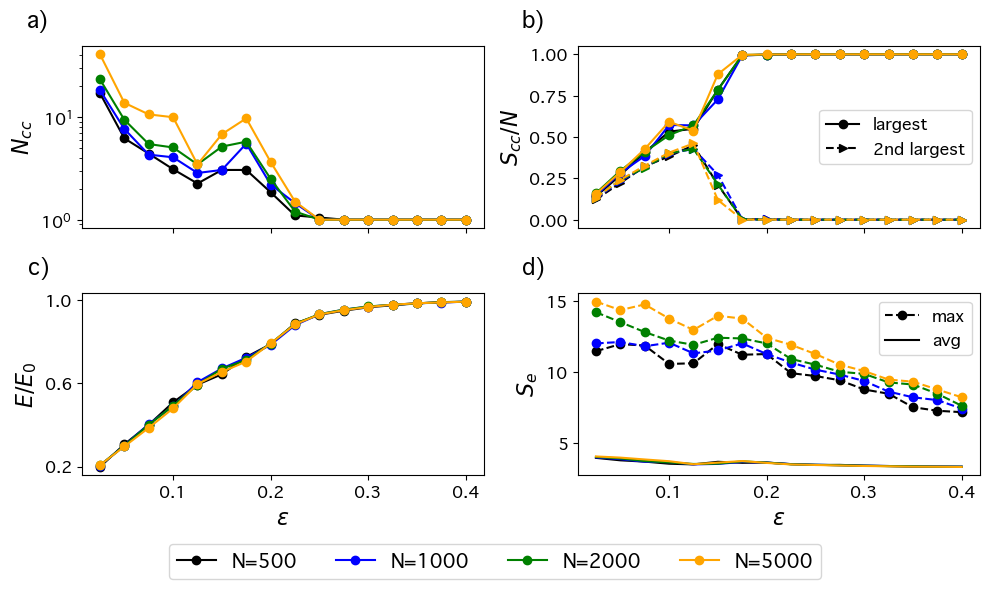

In [23]:
s_str = '246'
cond = 'std'

with open(f'../results/ER_{cond}/ER_{cond}_M{s_str}.pkl', 'rb') as f:
    res = pickle.load(f)

colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbls = ['largest', '2nd largest', 'avg', 'max']
lgd_size = 12
ttl_size = 16
# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

Ns = [500, 1000, 2000, 5000]
nrows, ncols = 2,2
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(10,6.5))

for N,clr in zip(Ns, colors):

    res_dict = res[N]
    epsilons = res_dict['epsilons']
    ncc = res_dict['ncc']
    scc1 = res_dict['scc1']
    scc2 = res_dict['scc2']
    nhe = res_dict['nhe']
    s_avg = res_dict['s_avg']
    s_max = res_dict['s_max']

    line1, = axs[0,0].plot(epsilons, ncc, color=clr, marker='o', label=f'N={N}')
    legend_handles.append(line1)
    legend_labels.append(f'N={N}')
    axs[0,0].set_yscale('log')
    axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[0] else None
    la1 = lbls[1] if N==Ns[0] else None
    axs[0,1].plot(epsilons, scc1, color=clr, linestyle='-', marker='o', label=la0)
    axs[0,1].plot(epsilons, scc2, color=clr, linestyle='--', marker='>', label=la1)
    axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    axs[0,1].legend(fontsize=lgd_size, loc=5)
        
    axs[1,0].plot(epsilons, nhe, color=clr, marker='o', label=f'N={N}')
    axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)
    axs[1,0].set_yticks([0.2,0.6,1.0])

    la2 = lbls[2] if N==Ns[0] else None
    la3 = lbls[3] if N==Ns[0] else None
    axs[1,1].plot(epsilons, s_max, label=la3, linestyle='--', marker='o', color=clr)
    axs[1,1].plot(epsilons, s_avg, label=la2, color=clr)
    axs[1,1].set_ylabel(r'$S_e$', fontsize=ttl_size)
    axs[1,1].legend(fontsize=lgd_size)

    # set xlabel tick fontsize in all subplots
    for j in range(ncols):
        axs[nrows-1,j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
        for i in range(nrows):
            axs[i,j].tick_params(labelsize=12)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.002),
           fontsize=14, ncol=len(Ns))

plt.tight_layout(rect=[0, 0.07, 1, 0.93])
plt.savefig(f'../figures/ER_{cond}_M{s_str}.jpg', dpi=dpi)
plt.show()

# Non-uniform ER - distributions for $\epsilon = 0.1$

N=500 ---> <k> = 5.0540929823157565
N=1000 ---> <k> = 5.164692938587717
N=2000 ---> <k> = 5.26009600960096
N=5000 ---> <k> = 5.2706458904246585


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1242/555326532.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


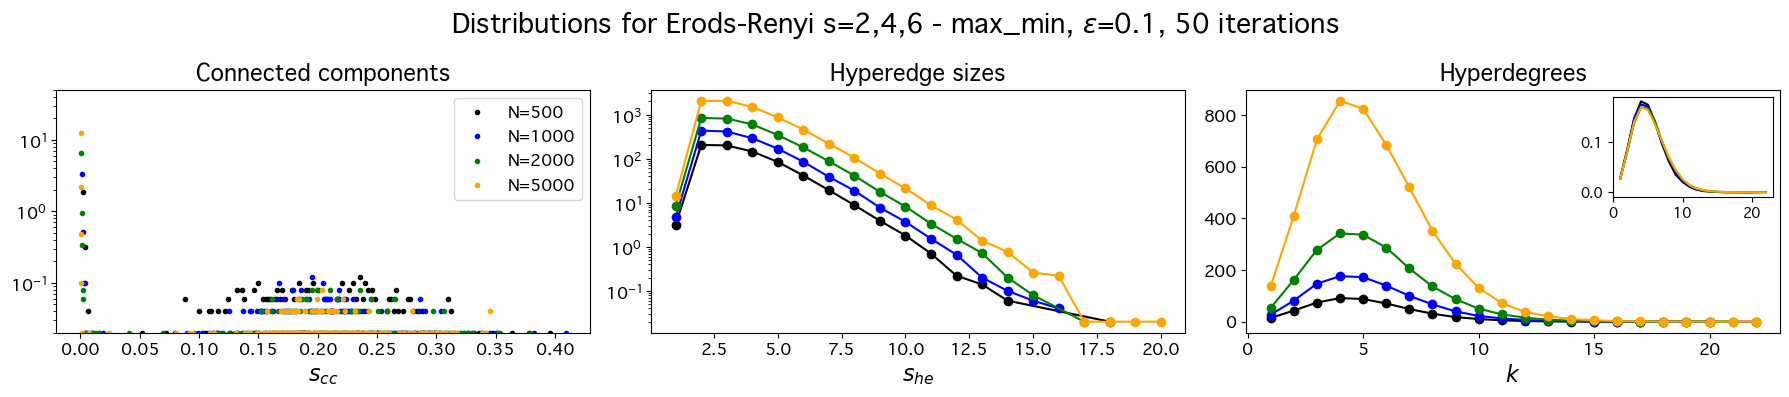

In [25]:
cond = 'max_min'
epsilon = 0.1
with open(f'../results/ER_{cond}/ER_{cond}_distrib_eps_{epsilon}M246.pkl', 'rb') as f:
    res = pickle.load(f)

colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbls = ['largest', '2nd largest', 'avg', 'max']
ttl_size = 16
lgd_size = 12

Ns = [500, 1000, 2000, 5000]
ncols = 3
fig, axs = plt.subplots(1,ncols, figsize=(18,4))
inset_ax = inset_axes(axs[2], width="30%", height=1.)

for N,clr in zip(Ns, colors):

    results = res[N]
    sizes_cc = results['sizes_cc']
    sizes_he = results['sizes_he']
    sizes_hd = results['sizes_hd']
    n_iter = results['n_iterations']
    ks_avg = results['ks_avg']
    
    x0 = [j/N for j in sorted(sizes_cc.keys())]
    y0 = [sizes_cc[j] for j in sorted(sizes_cc.keys())]
    axs[0].plot(x0, y0, color=clr, marker='o', markersize=3, linewidth=0, label=f'N={N}')
    axs[0].set_yscale('log')
    axs[0].set_ylim([1/n_iter, n_iter])
    axs[0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
    axs[0].set_title('Connected components', rotation=0, fontsize=ttl_size)
    axs[0].legend(fontsize=lgd_size)

    x1 = sorted(sizes_he.keys())
    y1 = [sizes_he[x] for x in x1]
    axs[1].plot(x1, y1, color=clr, marker='o', label=f'N={N}')
    axs[1].set_yscale('log')
    axs[1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
    axs[1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

    x2 = sorted(sizes_hd.keys())
    y2 = [sizes_hd[x] for x in x2]
    axs[2].plot(x2, y2, color=clr, marker='o', label=f'N={N}')
    axs[2].set_xlabel(r'$k$', fontsize=ttl_size)
    axs[2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)
    # inset plots
    y2_norm = [i/N for i in y2]
    inset_ax.plot(x2, y2_norm, color=clr)

    # print avg hyperdegree
    hd_avg = np.dot(x2, y2) / sum(y2)
    print(f'N={N} ---> <k> = {hd_avg}')

    # set tick fontsize in all subplots
    for j in range(ncols):
        axs[j].tick_params(labelsize=12)

plt.suptitle(rf'Distributions for Erods-Renyi s={s_str[0]},{s_str[1]},{s_str[2]} - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/ER_s{s_str}_{cond}_distributions_eps_{epsilon}.jpg', dpi=dpi)
plt.show()

# SocioPatterns hypergraph

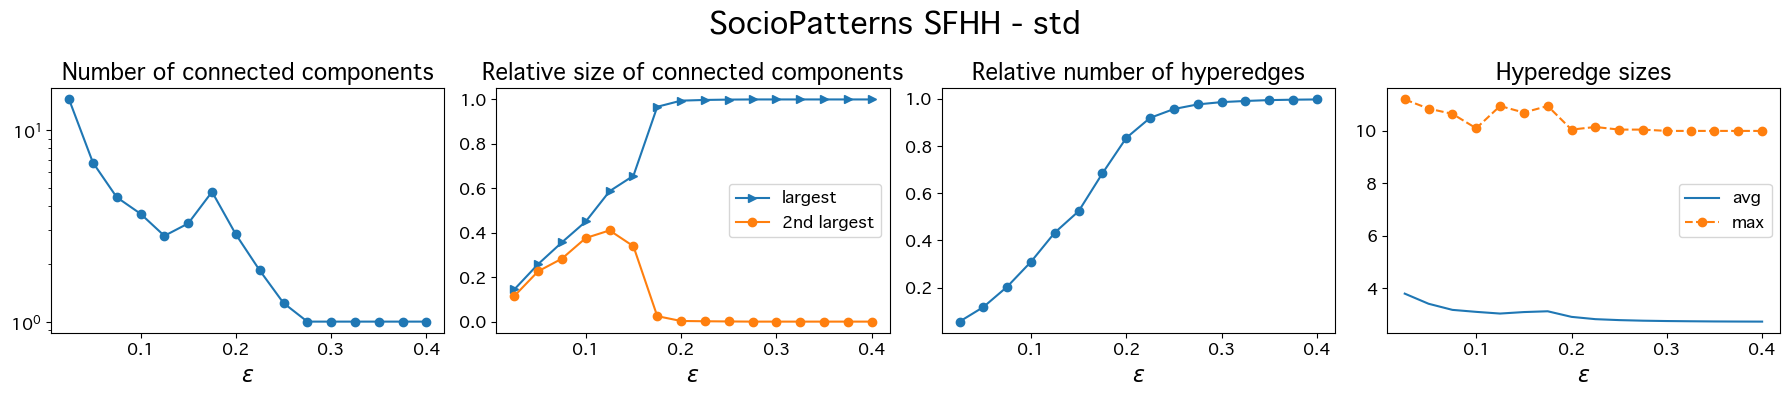

In [28]:
tag = 'SFHH'
cond = 'std'
with open(f'../results/SocioPatterns/SP_{tag}_{cond}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
ttl_size = 16
lgd_size = 12
ncols = 4

fig, axs = plt.subplots(1,ncols, figsize=(18,4))

axs[0].plot(epsilons, ncc, marker='o')
#axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('Number of connected components', fontsize=ttl_size)

axs[1].plot(epsilons, scc1, linestyle='-', marker='>', label=lbls[0])
axs[1].plot(epsilons, scc2, linestyle='-', marker='o', label=lbls[1])
axs[1].legend(fontsize=lgd_size)
axs[1].set_title('Relative size of connected components', fontsize=ttl_size)
    
axs[2].plot(epsilons, nhe, marker='o')
axs[2].set_title('Relative number of hyperedges', fontsize=ttl_size)

axs[3].plot(epsilons, s_avg, label=lbls[2])
axs[3].plot(epsilons, s_max, label=lbls[3], linestyle='--', marker='o')
axs[3].legend(fontsize=lgd_size)
axs[3].set_title('Hyperedge sizes', fontsize=ttl_size)

# set xlabel tick fontsize in all subplots
for j in range(ncols):
    axs[j].tick_params(labelsize=12)
    axs[j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)

plt.suptitle(f'SocioPatterns SFHH - {cond}', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}.jpg', dpi=dpi)
plt.show()

<k> = 9.992555831265507


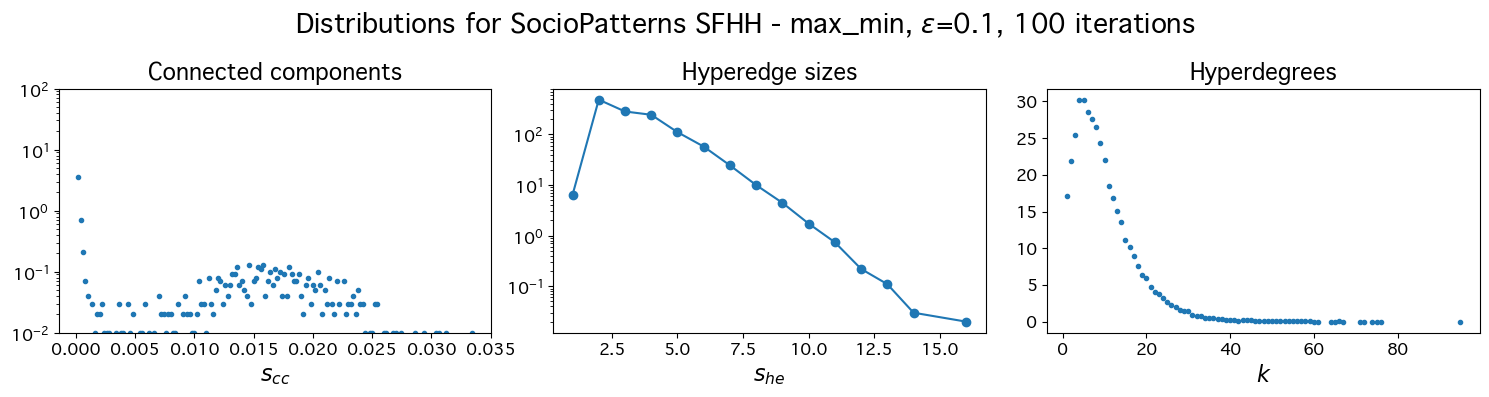

In [30]:
tag = 'SFHH'
cond = 'max_min'
epsilon = 0.1
with open(f'../results/SocioPatterns/SP_{tag}_{cond}_distributions_eps_{epsilon}.pkl', 'rb') as f:
    results = pickle.load(f)

sizes_cc = results['sizes_cc']
sizes_he = results['sizes_he']
sizes_hd = results['sizes_hd']
n_iter = results['n_iterations']

ncol = 3
fig, axs = plt.subplots(1, ncol, figsize=(15, 4))
ttl_size = 16
lgd_size = 12

x0 = [j/N for j in sorted(sizes_cc.keys())]
y0 = [sizes_cc[j] for j in sorted(sizes_cc.keys())]
axs[0].plot(x0, y0, marker='o', markersize=3, linewidth=0)
axs[0].set_yscale('log')
axs[0].set_ylim([1/n_iter, n_iter])
axs[0].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
axs[0].set_title('Connected components', rotation=0, fontsize=ttl_size)

x1 = sorted(sizes_he.keys())
y1 = [sizes_he[x] for x in x1]
axs[1].plot(x1, y1, marker='o')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
axs[1].set_title('Hyperedge sizes', rotation=0, fontsize=ttl_size)

x2 = sorted(sizes_hd.keys())
y2 = [sizes_hd[x] for x in x2]
axs[2].plot(x2, y2, marker='o', markersize=3, linewidth=0)
axs[2].set_xlabel(r'$k$', fontsize=ttl_size)
axs[2].set_title('Hyperdegrees', rotation=0, fontsize=ttl_size)

# print avg hyperdegree
hd_avg = np.dot(x2, y2) / sum(y2)
print(f'<k> = {hd_avg}')

# set tick fontsize in all subplots
for j in range(ncol):
    axs[j].tick_params(labelsize=12)
    

plt.suptitle(fr'Distributions for SocioPatterns SFHH - {cond}, $\epsilon$={epsilon}, {n_iter} iterations',
             fontsize=int(ttl_size*1.2))

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}_distributions_eps_{epsilon}.jpg')
plt.show()

# Temporal evolution of hyperedges

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1242/2604006882.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend


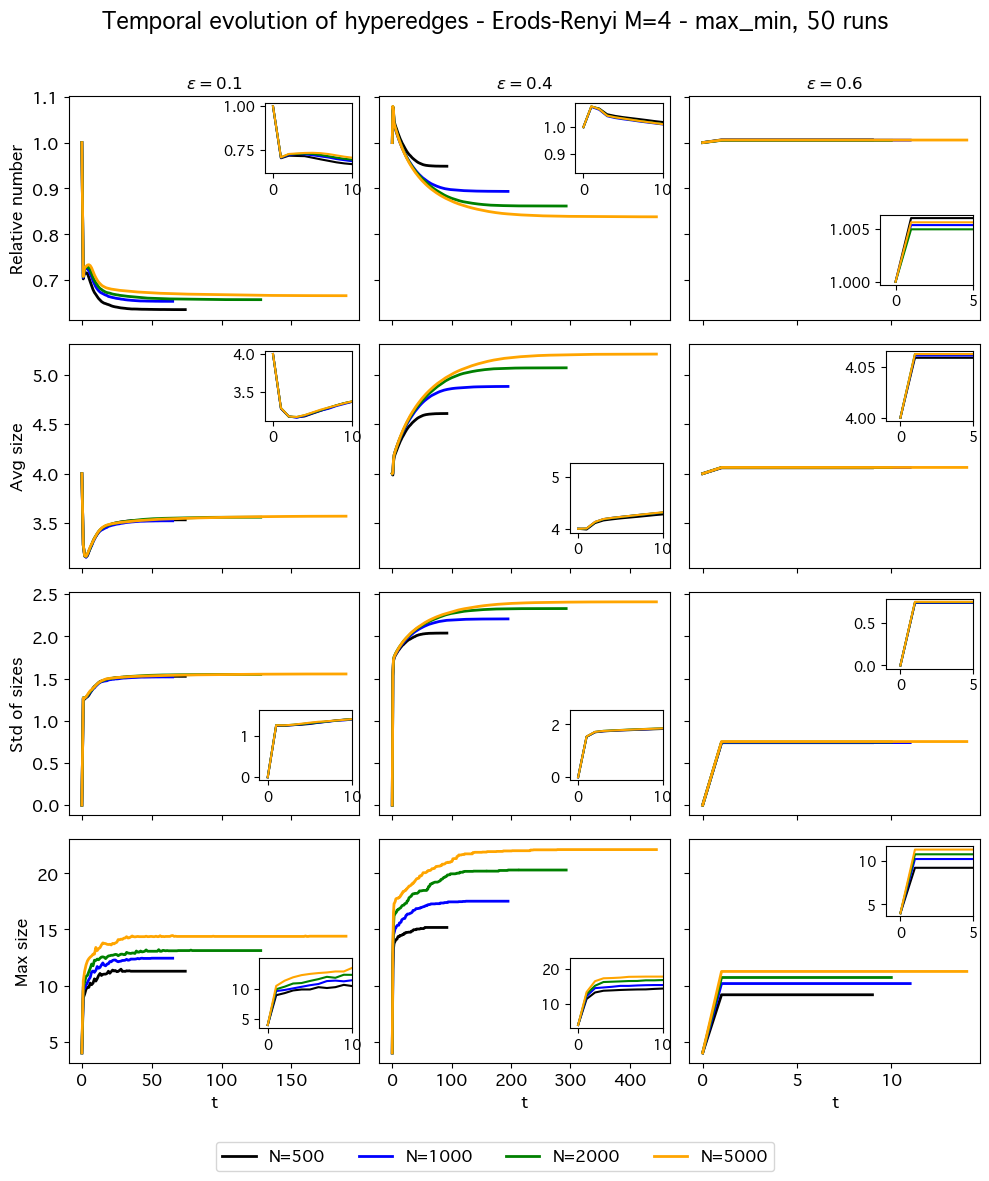

In [33]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4, 0.6]

fig, axs = plt.subplots(4, len(epsilons), sharex='col', sharey='row', figsize=(10,12))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Relative number', 'Avg size', 'Std of sizes', 'Max size']

# We'll collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_{cond}/ER_M{M}_{cond}_epsilon_{eps}_temporal.pkl', 'rb') as f:
        results = pickle.load(f)

    xlim = 10
    if j==2:
        xlim=5
    inset_ax = []
    cr = [(0,2),(1,1),(2,0),(2,1),(3,0),(3,1)]
    for i in range(4):
        if (i,j) in cr:
            inset_ax.append( inset_axes(axs[i, j], width="40%", height=0.7, bbox_to_anchor=(.2, .3, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )
        else:
            inset_ax.append( inset_axes(axs[i, j], width="30%", height=0.7, loc=1) )

    for N, clr in zip(Ns, colors):
        nhe = results[N]['nhe']
        s_avg = results[N]['s_avg']
        s_max = results[N]['s_max']
        s_std = results[N]['s_std']
        n_runs = results[N]['n_runs']
        k_avg = results[N]['k_avg']

        line1, = axs[0, j].plot(nhe, color=clr, lw=2, label=f'N={N}')
        inset_ax[0].set_xlim(-1, xlim)
        inset_ax[0].plot(nhe, color=clr)

        axs[1, j].plot(s_avg, color=clr, lw=2)
        inset_ax[1].set_xlim(-1, xlim)
        inset_ax[1].plot(s_avg, color=clr)

        axs[2, j].plot(s_std, color=clr, lw=2)
        inset_ax[2].set_xlim(-1, xlim)
        inset_ax[2].plot(s_std, color=clr)

        axs[3, j].plot(s_max, color=clr, lw=2)
        axs[3, j].set_xlabel(r't', fontsize=lgd_size)
        inset_ax[3].set_xlim(-1, xlim)
        inset_ax[3].plot(s_max, color=clr)            

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=lgd_size)

    for i in range(4):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=lgd_size)
        axs[i, j].tick_params(labelsize=lgd_size)

# Super title
plt.suptitle(f'Temporal evolution of hyperedges - Erods-Renyi M={M} - {cond}, {n_runs} runs', fontsize=ttl_size)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.005),
           fontsize=lgd_size, ncol=len(Ns))

plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_hedges.jpg', bbox_inches='tight', dpi=dpi)
plt.show()

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1242/4180490091.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend


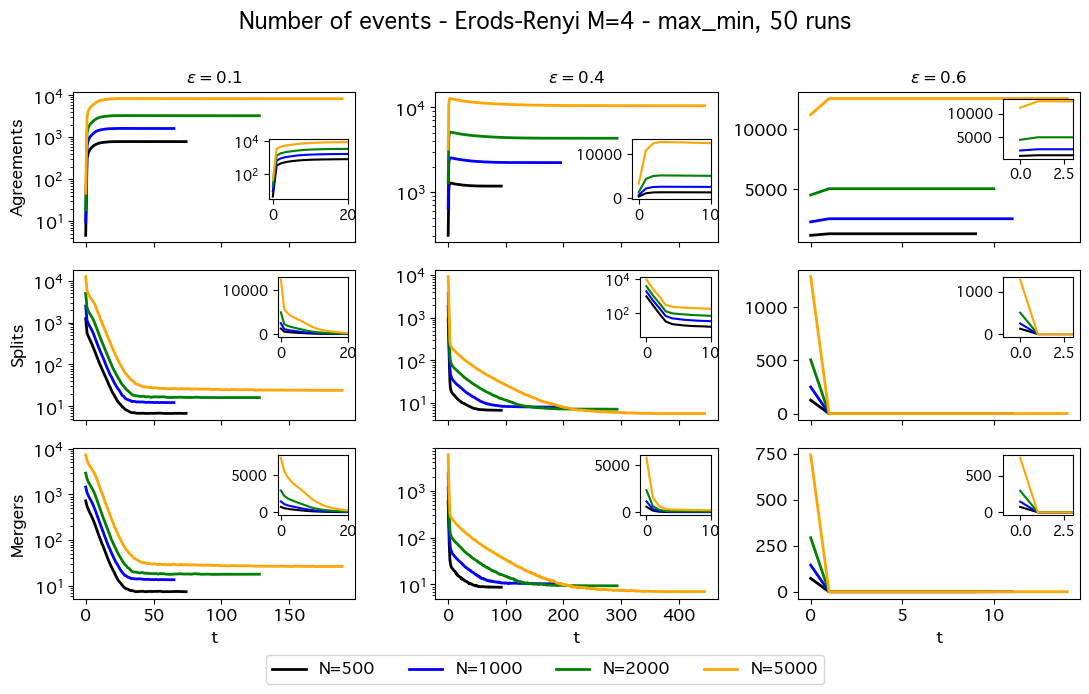

In [35]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4, 0.6]

fig, axs = plt.subplots(3, len(epsilons), sharex='col', figsize=(11,7))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']
xlims = [20,10,3]   # for inset plots

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_{cond}/ER_M{M}_{cond}_epsilon_{eps}_temporal.pkl', 'rb') as f:
        results = pickle.load(f)

    inset_ax = []
    cr = [(0,0),(0,1)]
    for i in range(3):
        if (i,j) in cr:
            inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.6, bbox_to_anchor=(.2, .53, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )
        else:
            inset_ax.append( inset_axes(axs[i, j], width="25%", height=0.6, loc=1) )

    for N, clr in zip(Ns, colors):
        n_agree = results[N]['n_agree']
        n_split = results[N]['n_split']
        n_merge = results[N]['n_merge']
        n_runs = results[N]['n_runs']
        k_avg = results[N]['k_avg']

        line1, = axs[0, j].plot(n_agree, color=clr, lw=2, label=f'N={N}')
        inset_ax[0].set_xlim(-1, xlims[j])
        inset_ax[0].plot(n_agree, color=clr)

        axs[1, j].plot(n_split, color=clr, lw=2)
        inset_ax[1].set_xlim(-1, xlims[j])
        inset_ax[1].plot(n_split, color=clr)

        axs[2, j].plot(n_merge, color=clr, lw=2)
        axs[2, j].set_xlabel(r't', fontsize=lgd_size)
        inset_ax[2].set_xlim(-1, xlims[j])
        inset_ax[2].plot(n_merge, color=clr)       

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=lgd_size)

    for i in range(3):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=lgd_size)
        axs[i, j].tick_params(labelsize=lgd_size)
        if j<2:
            axs[i, j].set_yscale('log')
            inset_ax[j].set_yscale('log')


plt.suptitle(f'Number of events - Erods-Renyi M={M} - {cond}, {n_runs} runs', fontsize=ttl_size)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.005),
           fontsize=lgd_size, ncol=len(Ns))

#plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_n_events.jpg', bbox_inches='tight')
plt.show()

# Checks on split-merge dynamics

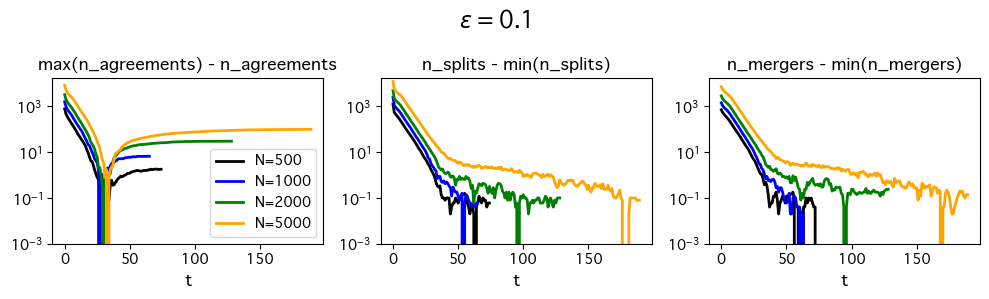

In [38]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    n_runs = results[N]['n_runs']
    k_avg = results[N]['k_avg']
    
    n_ag = [max(n_agree) - i for i in n_agree]
    n_sp = [i - min(n_split) for i in n_split]
    n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_ag, color=clr, lw=2, label=f'N={N}')
    ax[1].plot(n_sp, color=clr, lw=2, label=f'N={N}')
    ax[2].plot(n_me, color=clr, lw=2, label=f'N={N}')
    ax[0].set_title('max(n_agreements) - n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits - min(n_splits)', fontsize=ttl_size)
    ax[2].set_title('n_mergers - min(n_mergers)', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.001, 17000)
        ax[i].set_yscale('log')

plt.suptitle(rf'$\epsilon =${epsilon}', fontsize=16)

plt.tight_layout()
plt.show()

# Single run to check what happens

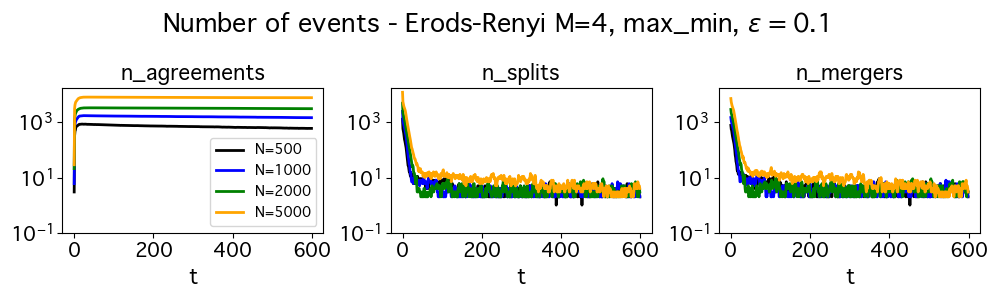

In [42]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    k_avg = results[N]['k_avg']
    
    #n_ag = [max(n_agree) - i for i in n_agree]
    #n_sp = [i - min(n_split) for i in n_split]
    #n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_agree, color=clr, lw=2, label=f'N={N}')
    ax[1].plot(n_split, color=clr, lw=2, label=f'N={N}')
    ax[2].plot(n_merge, color=clr, lw=2, label=f'N={N}')
    ax[0].set_title('n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits', fontsize=ttl_size)
    ax[2].set_title('n_mergers', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].tick_params(labelsize=14)
        ax[i].set_yscale('log')
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.1, 17000)
            
plt.suptitle(rf'Number of events - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=18)

plt.tight_layout()
plt.show()

N=500
Final number of different opinions:  7
Final clusters of opinions:  {0.6667: 141, 0.3771: 123, 0.9064: 102, 0.1495: 124, 0.275: 1, 0.8052: 1, 0.0288: 8} 

N=1000
Final number of different opinions:  7
Final clusters of opinions:  {0.6075: 341, 0.3064: 238, 0.1058: 180, 0.9989: 1, 0.8794: 237, 0.4545: 2, 0.9898: 1} 

N=2000
Final number of different opinions:  7
Final clusters of opinions:  {0.109: 375, 0.5131: 470, 0.9054: 376, 0.3027: 346, 0.7136: 431, 0.0048: 1, 0.0008: 1} 

N=5000
Final number of different opinions:  9
Final clusters of opinions:  {0.4993: 1243, 0.2905: 1047, 0.7114: 861, 0.0977: 855, 0.8917: 987, 0.9957: 3, 0.9988: 2, 0.9943: 1, 0.3917: 1} 



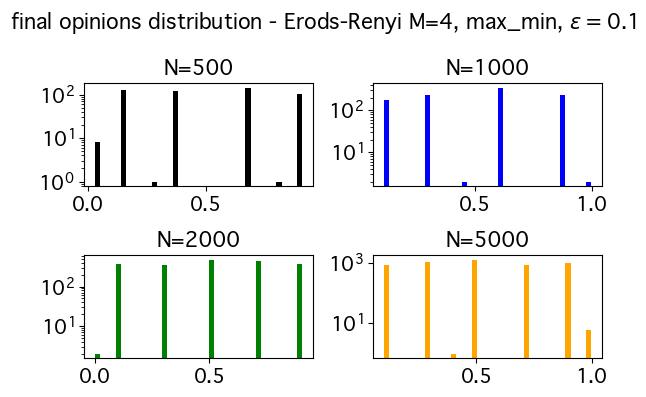

In [44]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_{cond}/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

fig, ax = plt.subplots(2,2, figsize=(6,4))

for i in range(len(Ns)):
    N, clr = Ns[i], colors[i]
    ops_dist = results[N]['final_opinions']
    nhe = results[N]['nhe']
    k_avg = results[N]['k_avg']

    j, k = int(i/2), i%2
    ax[j,k].hist(ops_dist, bins=40, color=clr)
    ax[j,k].set_title(f'N={N}', fontsize=ttl_size)

    for i in range(4):
        ax[j,k].tick_params(labelsize=14)
        ax[j,k].set_yscale('log')

    ops_dist = [np.round(i,4) for i in ops_dist]
    unique_ops = list(set(ops_dist))
    clst_op = {i :ops_dist.count(i) for i in unique_ops}
    print(f'N={N}')
    print('Final number of different opinions: ', len(unique_ops) )
    print(f'Final clusters of opinions: ', clst_op, '\n' )

plt.suptitle(rf'final opinions distribution - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=ttl_size)

plt.tight_layout()
plt.show()

# Bimodal distribution of initial opinions

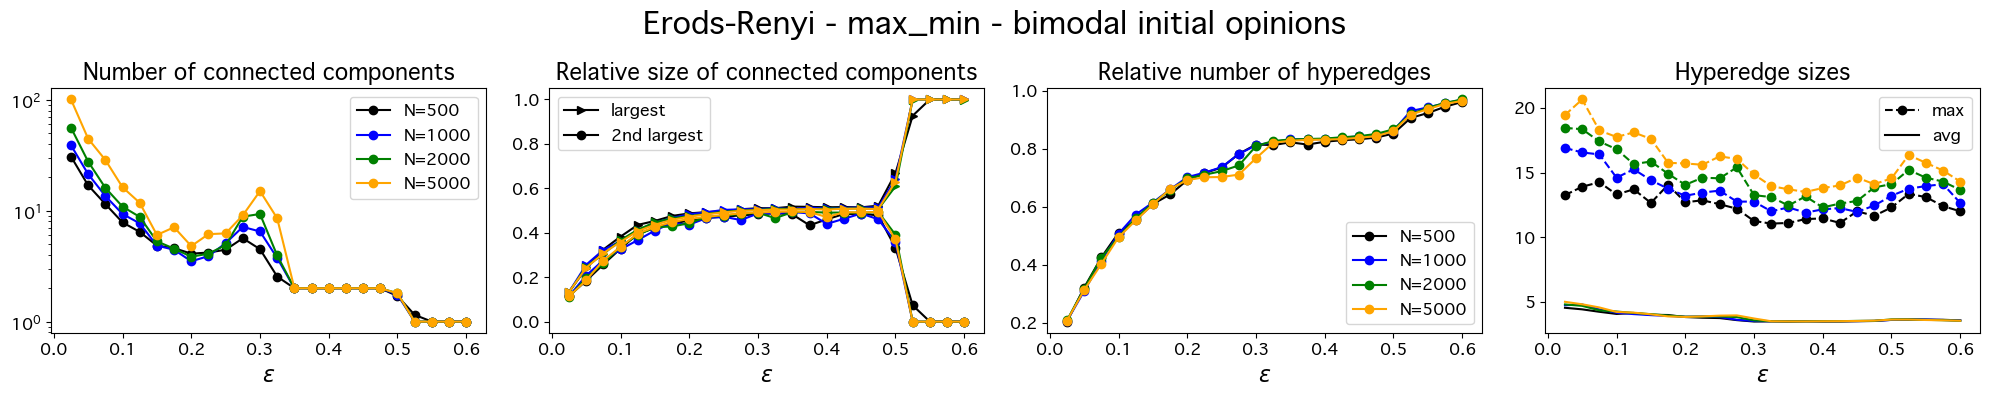

In [6]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
means = '0.0_1.0'

ncol = 4
fig, axs = plt.subplots(1, ncol, figsize=(20, 4))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N


with open(f'../results/ER_{cond}/ER_{cond}_bimodal_{means}_M246.pkl', 'rb') as f:  
    results = pickle.load(f)
    
epsilons = results['epsilons']
ncc = results['ncc']
scc1 = results['scc1']
scc2 = results['scc2']
nhe = results['nhe']
s_avg = results['s_avg']
s_max = results['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
for N,clr in zip(Ns, colors):
                               
    y0 = ncc[N]
    y1 = scc1[N]
    y2 = scc2[N]
    y3 = nhe[N]
    y4 = s_avg[N]
    y5 = s_max[N]
    
    axs[0].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
    axs[0].set_yscale('log')
    axs[0].legend(fontsize=lgd_size)
    axs[0].set_title('Number of connected components', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[0] else None
    la1 = lbls[1] if N==Ns[0] else None
    axs[1].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=la0)
    axs[1].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=la1)
    axs[1].legend(fontsize=lgd_size)
    axs[1].set_title('Relative size of connected components', fontsize=ttl_size)
    
    axs[2].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')
    axs[2].legend(fontsize=lgd_size)
    axs[2].set_title('Relative number of hyperedges', fontsize=ttl_size)

    la2 = lbls[2] if N==Ns[0] else None
    la3 = lbls[3] if N==Ns[0] else None
    axs[3].plot(epsilons, y5, label=la3, linestyle='--', marker='o', color=clr)
    axs[3].plot(epsilons, y4, label=la2, color=clr)
    axs[3].legend(fontsize=lgd_size)
    axs[3].set_title('Hyperedge sizes', fontsize=ttl_size)

    # set tick fontsize in all subplots
    for j in range(4):
        axs[j].tick_params(labelsize=12)

for j in range(ncol):
    axs[j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    
plt.suptitle(f'Erods-Renyi - {cond} - bimodal initial opinions', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_bimodal_{means}_M246.jpg')
plt.show()